## Loading the DataSet

In [371]:
import pandas as pd
import numpy as np
df=pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Knowing the DataSet

In [372]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 337.3 KB


## Statistical Information of Data

In [373]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [374]:
df.dtypes

Year                      int64
Month                     int64
Region                      str
Model                       str
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type                 str
Charging_Stations         int64
dtype: object

## Duplicates Check

In [375]:
df.duplicated().sum()

np.int64(0)

In [376]:
for i in df.select_dtypes(include='str').columns:
    print(df[i].value_counts())

Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64


## Exploratory Data Analysis

In [377]:
eda_req=['Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km','CO2_Saved_tons', 'Charging_Stations']

In [378]:
df['Estimated_Deliveries'].describe()

count     2640.000000
mean      9922.199621
std       3935.950093
min         48.000000
25%       7292.000000
50%       9857.000000
75%      12510.250000
max      25704.000000
Name: Estimated_Deliveries, dtype: float64

## Univariate Analysis

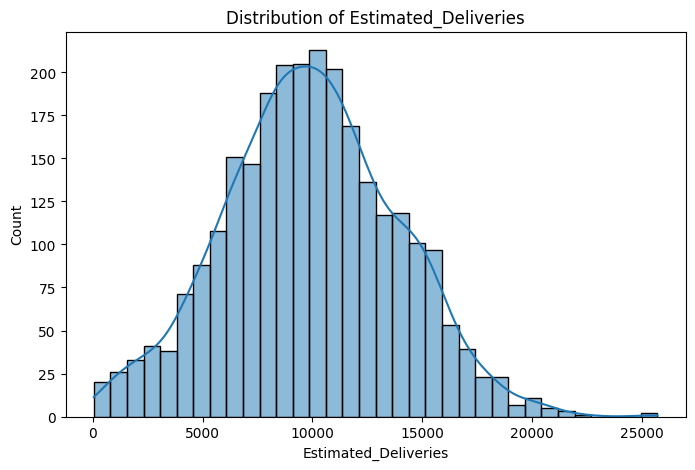

In [379]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df['Estimated_Deliveries'],kde=True)
plt.xlabel('Estimated_Deliveries')
plt.title('Distribution of Estimated_Deliveries')
plt.show()

The Deliveries follows a rough normal distribution, majority of the data lies near the mean and it's little right skewed

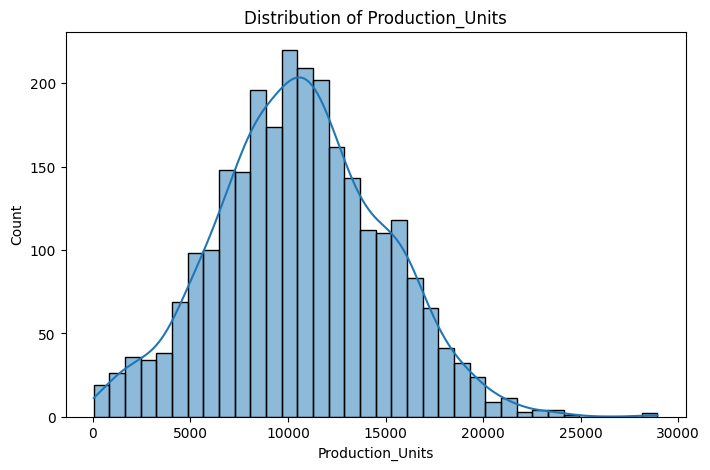

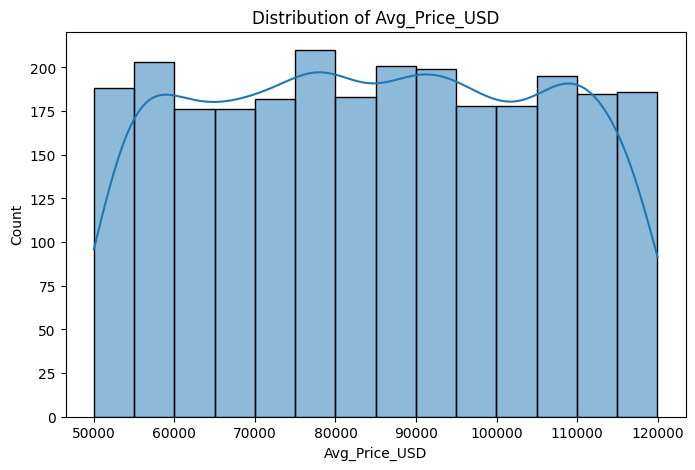

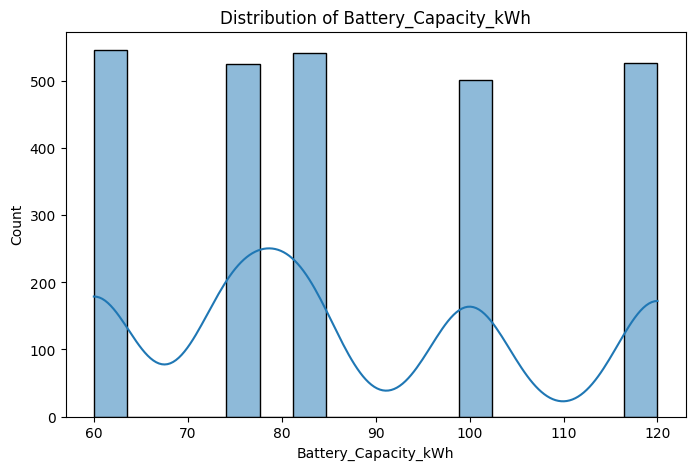

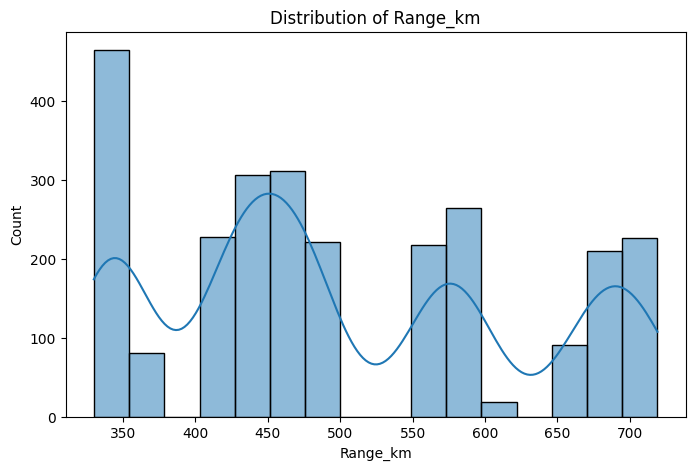

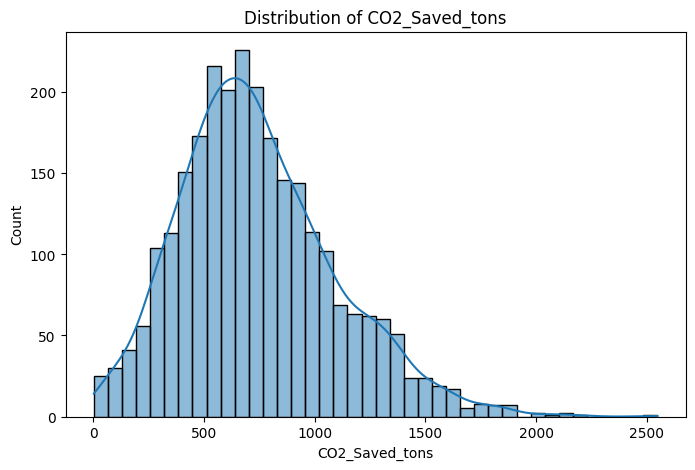

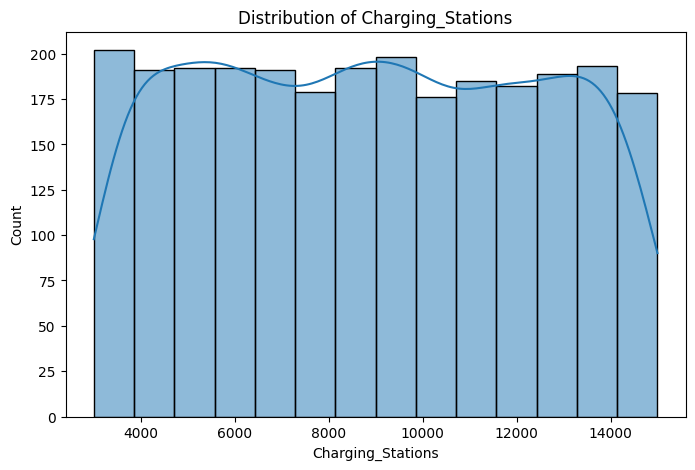

In [380]:
for i in eda_req:
    plt.figure(figsize=(8,5))
    sns.histplot(df[i],kde=True)
    plt.xlabel(f'{i}')
    plt.title(f'Distribution of {i}')
    plt.show()

Production_Units and CO2_Saved_tons are normally distributed(bell shaped distribution) others show a uniform Spread across ranges 

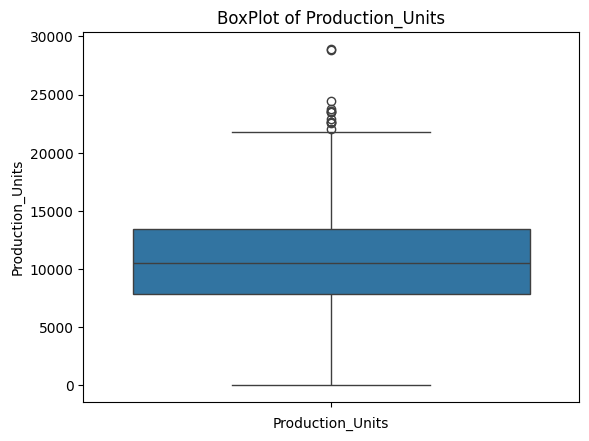

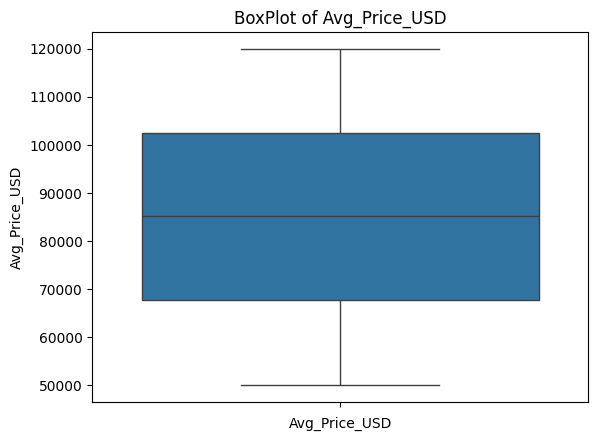

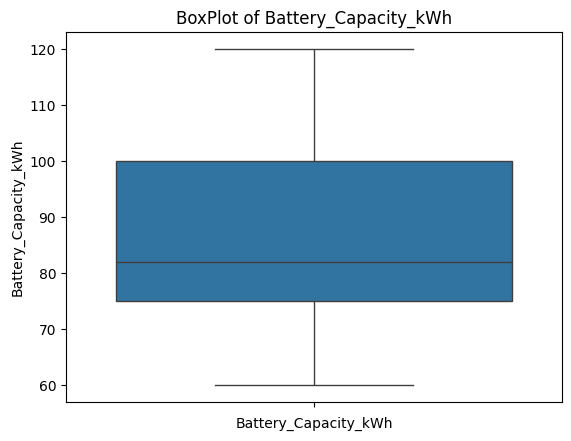

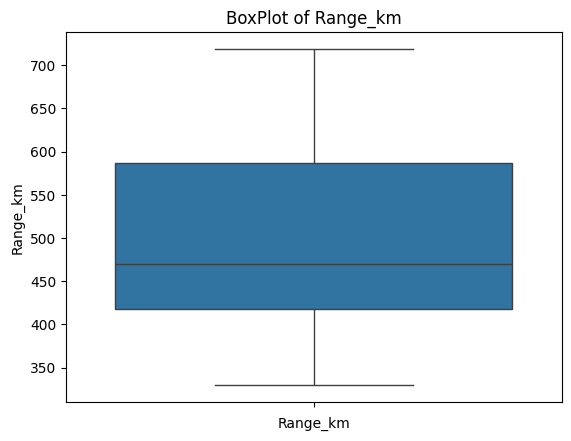

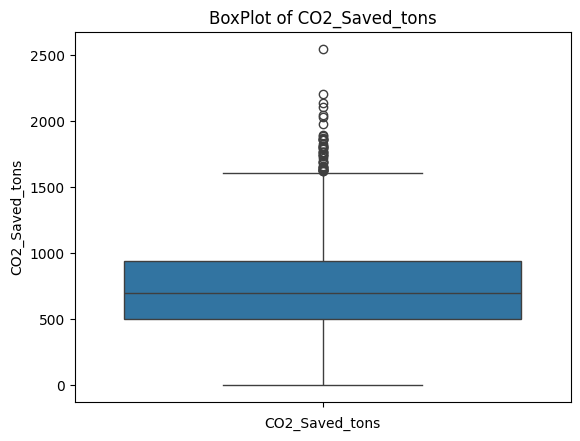

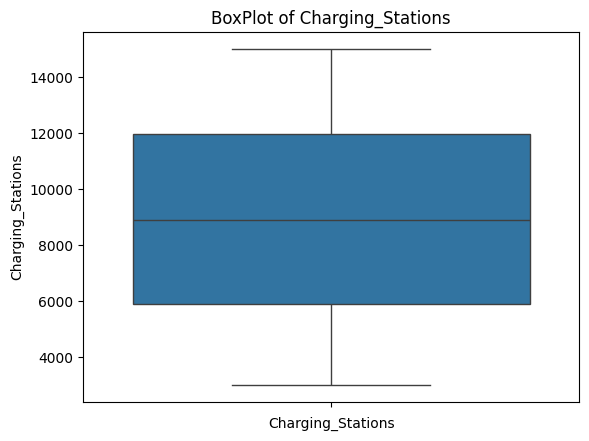

In [381]:
for i in eda_req:
    sns.boxplot(y=df[i])
    plt.xlabel(f'{i}')
    plt.title(f'BoxPlot of {i}')
    plt.show()

Production_Units and CO2_Saved_tons are seems to have Statistical Outliers but based on the domain knowledge the values are possible for a tesla manufacturing factory. So no Outlier handling required after Splitting

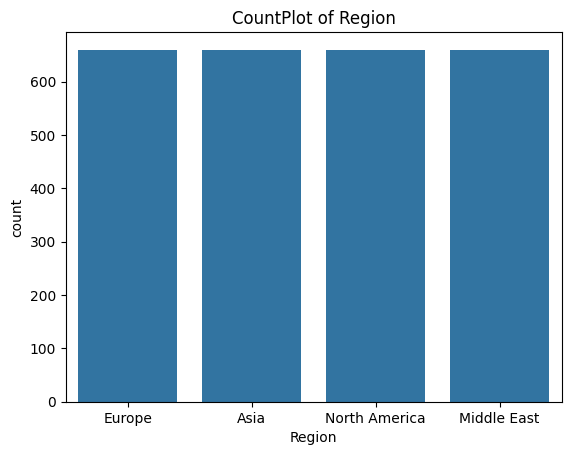

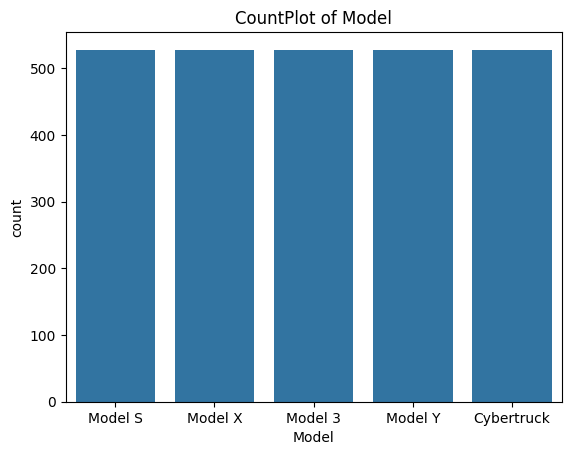

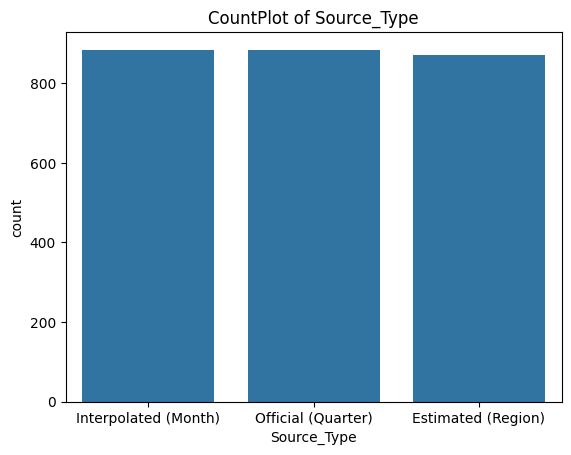

In [382]:
cat=df.select_dtypes(include='str').columns
for i in cat:
    sns.countplot(x=df[i])
    plt.xlabel(f'{i}')
    plt.title(f'CountPlot of {i}')
    plt.show()

The categorical columns have similar frequency distribution across classes

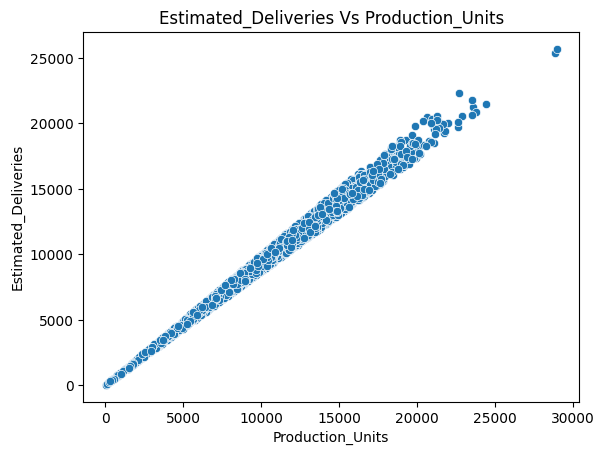

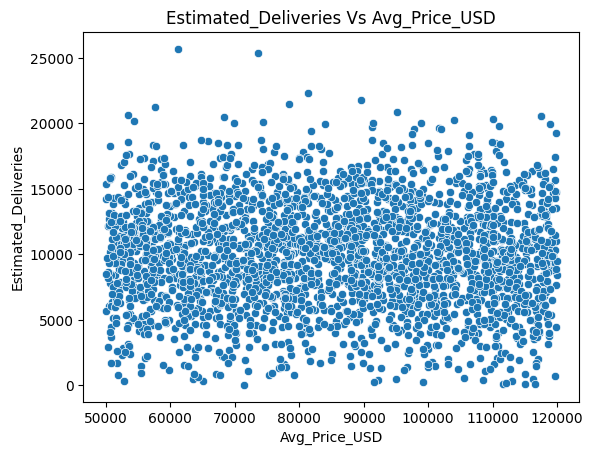

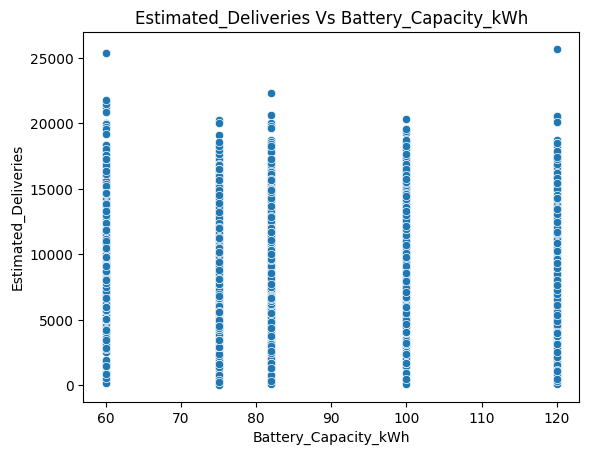

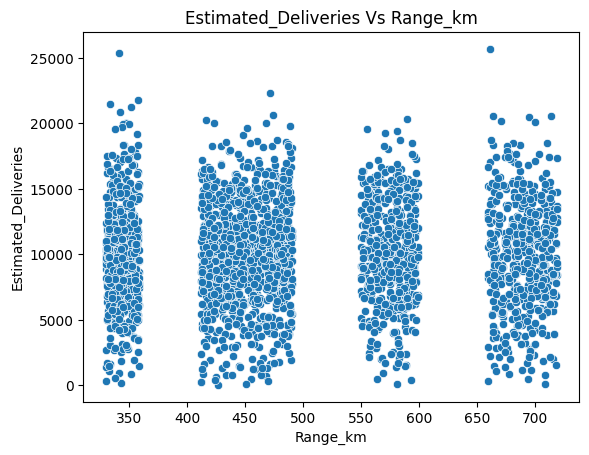

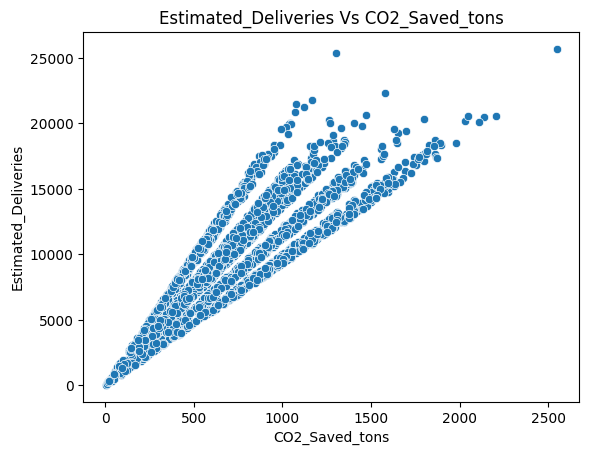

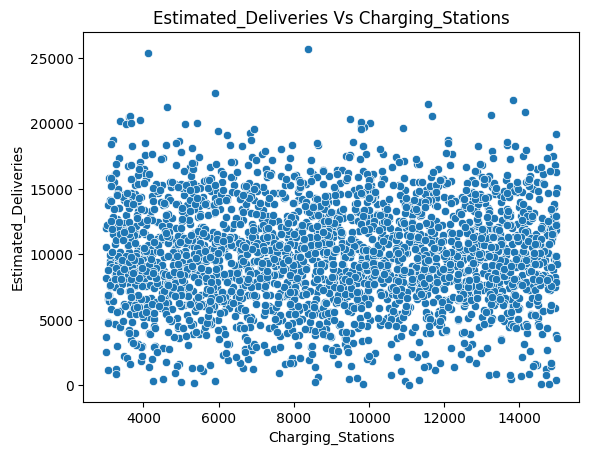

In [383]:
for i in eda_req:
    sns.scatterplot(x=df[i],y=df['Estimated_Deliveries'])
    plt.title(f'Estimated_Deliveries Vs {i}')
    plt.xlabel(f'{i}')
    plt.ylabel('Estimated_Deliveries')
    plt.show()

Production_Units and CO2_Saved_tons have a Strong Positive relationship with the Estimated_Deliveries

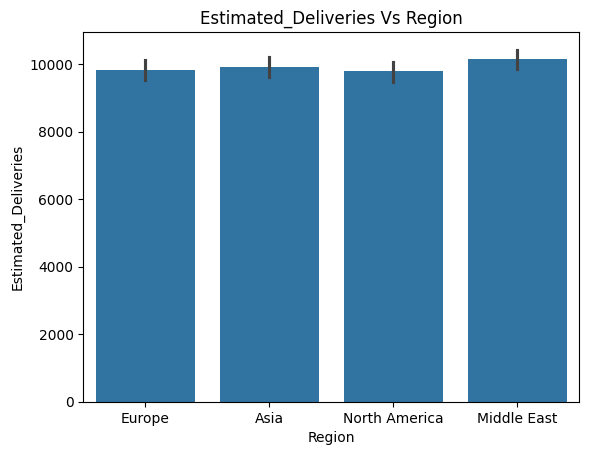

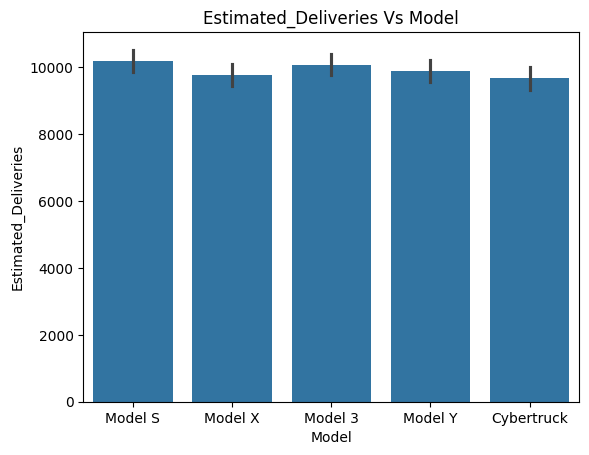

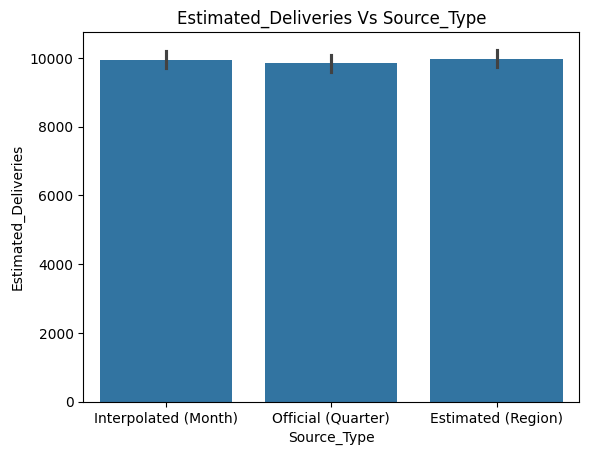

In [384]:
for i in cat:
    sns.barplot(x=df[i],y=df['Estimated_Deliveries'])
    plt.title(f'Estimated_Deliveries Vs {i}')
    plt.xlabel(f'{i}')
    plt.ylabel('Estimated_Deliveries')
    plt.show()

The average Estimated_Deliveries remain relatively consistent across categorical groups

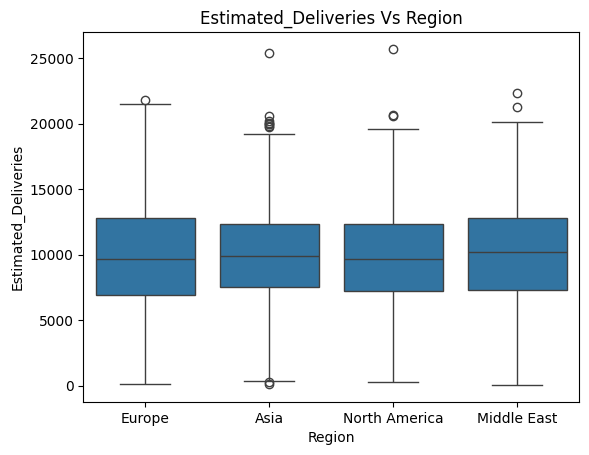

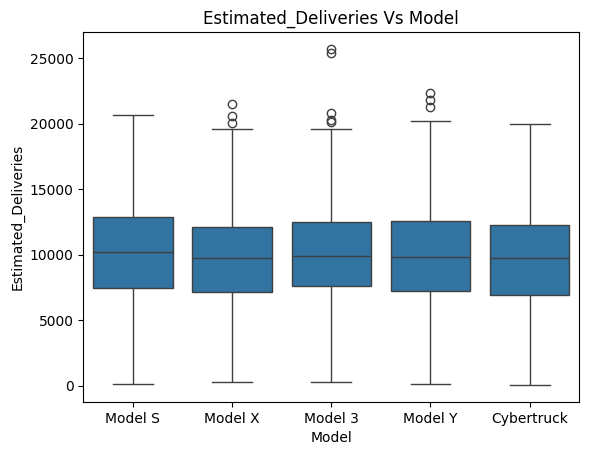

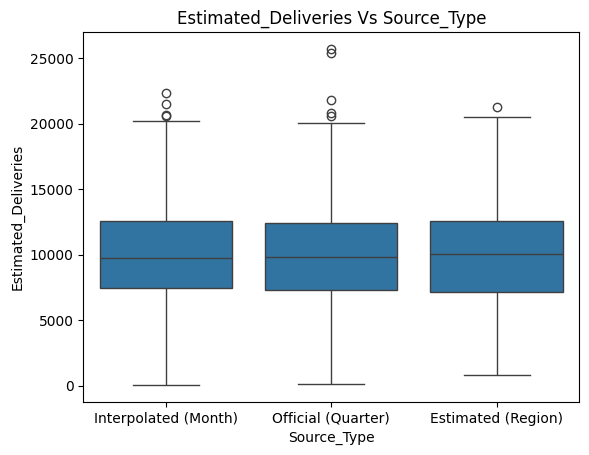

In [385]:
for i in cat:
    sns.boxplot(x=df[i],y=df['Estimated_Deliveries'])
    plt.title(f'Estimated_Deliveries Vs {i}')
    plt.xlabel(f'{i}')
    plt.ylabel('Estimated_Deliveries')
    plt.show()

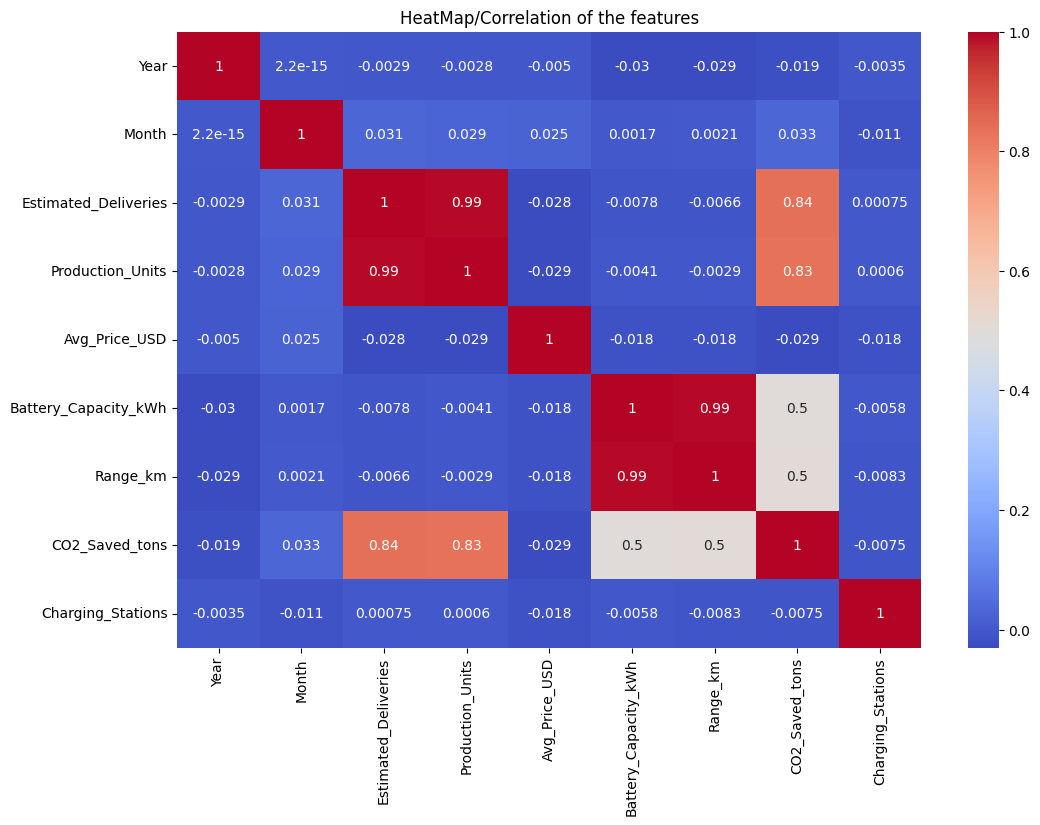

In [386]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,cmap='coolwarm')
plt.title('HeatMap/Correlation of the features')
plt.show()

The Estimated_Deliveries have a strong positive correlation Production_units and the CO2_Saved_tons

The Production_units and the CO2_Saved_tons has strong positive correlation

Battery_Capacity_kWh and Range_km are highly correlated

## Time Series Analysis

In [387]:
df['Date']=pd.to_datetime(df['Year'].astype(str)+'-'+df['Month'].astype(str))

In [388]:
df['Quarter']=((df['Month']-1)//3)+1

In [389]:
df['Quarter'].value_counts()

Quarter
2    660
1    660
4    660
3    660
Name: count, dtype: int64

In [390]:
df['Revenue']=(df['Avg_Price_USD']*df['Estimated_Deliveries'])

## Trend Analysis

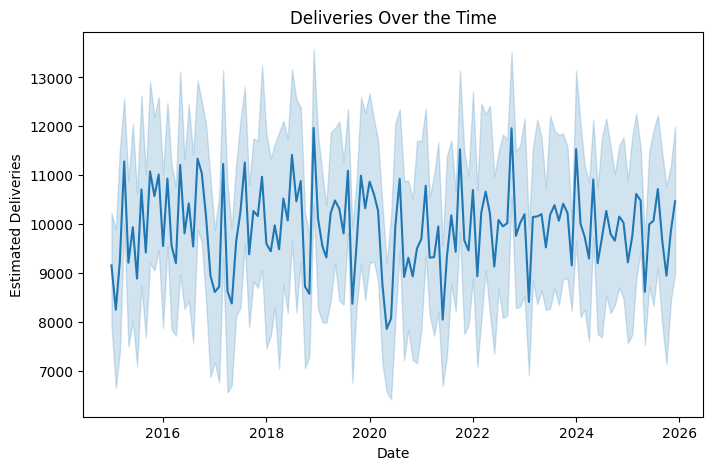

In [391]:
plt.figure(figsize=(8,5))
sns.lineplot(x=df['Date'],y=df['Estimated_Deliveries'])
plt.title("Deliveries Over the Time")
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.show()

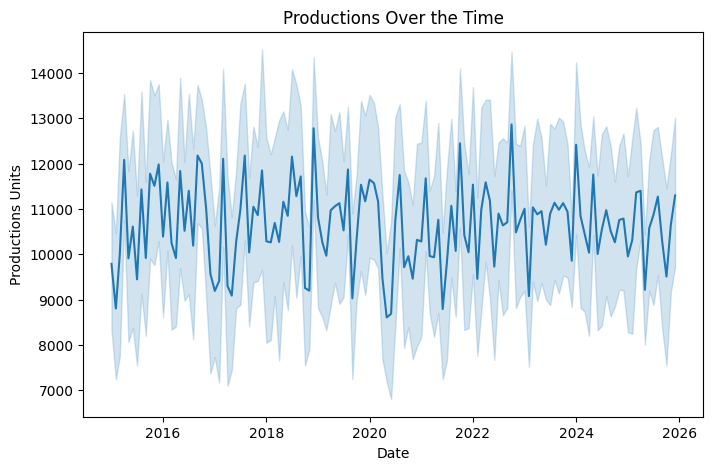

In [392]:
plt.figure(figsize=(8,5))
sns.lineplot(x=df['Date'],y=df['Production_Units'])
plt.title("Productions Over the Time")
plt.xlabel('Date')
plt.ylabel('Productions Units')
plt.show()

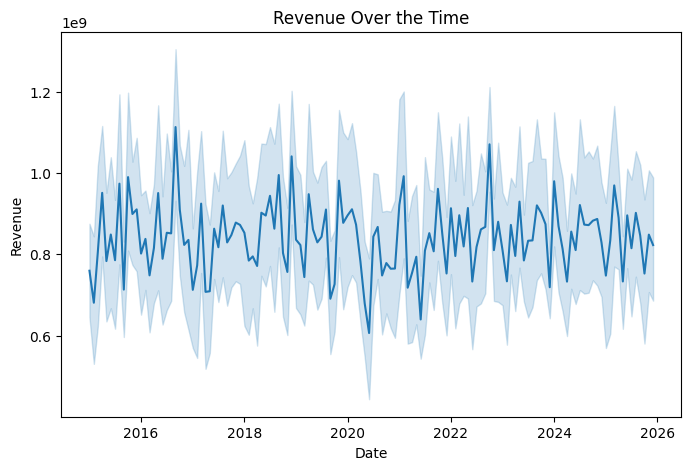

In [393]:
plt.figure(figsize=(8,5))
sns.lineplot(x=df['Date'],y=df['Revenue'])
plt.title("Revenue Over the Time")
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.show()

## Trend Analysis Insights

- Deliveries generally increase over time.
- Production exhibits similar behavior, indicating a strong relationship between production and deliveries.
- Revenue shows an upward trend mostly due to increased production and deliveries.

## Seasonality Analysis

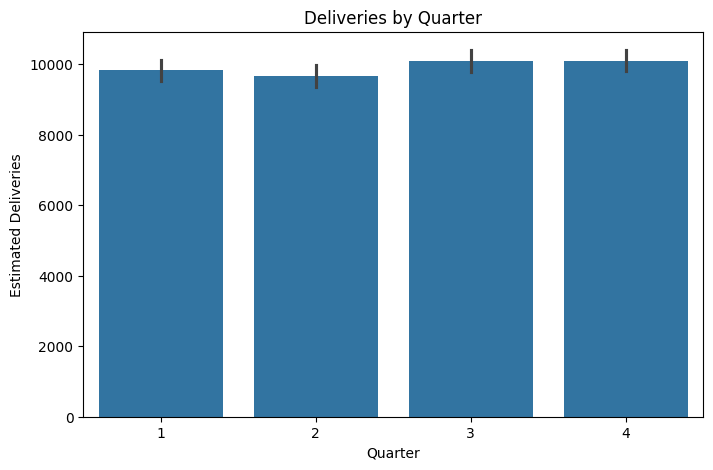

In [394]:
plt.figure(figsize=(8,5))
sns.barplot(x=df['Quarter'],y=df['Estimated_Deliveries'])
plt.title("Deliveries by Quarter")
plt.xlabel('Quarter')
plt.ylabel('Estimated Deliveries')
plt.show()

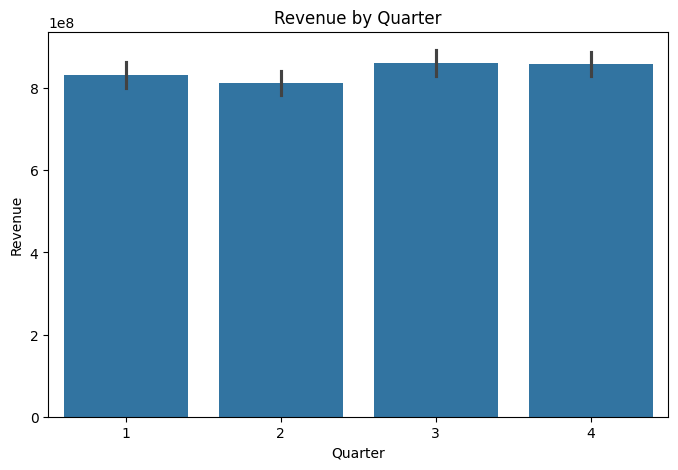

In [395]:
plt.figure(figsize=(8,5))
sns.barplot(x=df['Quarter'],y=df['Revenue'])
plt.title("Revenue by Quarter")
plt.xlabel('Quarter')
plt.ylabel('Revenue')
plt.show()

## Seasonality Insights

- Delivery volumes vary across quarters.
- Quarters 3 and 4 consistently demonstrate higher average deliveries and revenue.

## Feature Engineering

Created:
- Quarter (Seasonality Feature)
- Revenue (Business Metric for EDA)
- Deliveries_Lag1 (Previous Month Deliveries)

The lag feature was created to capture temporal dependencies for forecasting.

In [396]:
df['Deliveries_Lag1']=df['Estimated_Deliveries'].shift(1)

In [397]:
# Dropping the 1st Month Row as it doesn't has any previous Deliveries
df.dropna(subset=['Deliveries_Lag1'],inplace=True)

### Sorting the DataFrame for TimeSeries Splitting

In [398]:
df.sort_values('Date',inplace=True)

In [399]:
x=df.drop(columns=['Estimated_Deliveries','Revenue','Date','Month'])
y=df['Estimated_Deliveries']

### TimeSeries Splitting (Train - Past Data & Test - Future Data)

In [400]:
# Time-based train-test split
split_idx=int(df.shape[0]*0.8)
x_train=x.iloc[:split_idx,:]
x_test=x.iloc[split_idx:,:]

In [401]:
print(x_train.shape)
print(x_test.shape)

(2111, 12)
(528, 12)


In [402]:
y_train=y.iloc[:split_idx]
y_test=y.iloc[split_idx:]

In [403]:
median=[]
mean=[]
for i in x_train.select_dtypes(include='number').columns:
    if abs(x_train[i].skew())>0.5:
        median.append(i)
    else:
        mean.append(i)

## Preprocessing

- Numerical features were imputed using mean/median strategies based on skewness.
- Categorical features were encoded using OneHotEncoder.
- Numerical features were standardized using StandardScaler.
- A ColumnTransformer and Pipeline were used to prevent data leakage.

In [404]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

mean_pipe=Pipeline([
    ('mean_imputer',SimpleImputer(strategy='mean')),
    ('Std_scaler',StandardScaler())
])
median_pipe=Pipeline([
    ('median_imputer',SimpleImputer(strategy='median')),
    ('Minmax_scaler',MinMaxScaler())
])

# NO Ordinal Pipeline as there are no nominal columns
nominal_pipe=Pipeline([
    ('mode_imputer',SimpleImputer(strategy='most_frequent')),
    ('Onehot_Encoder',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'))
])

# Preprocessing Pipeline
preprocessor=ColumnTransformer(transformers=[
    ('mean_cols',mean_pipe,mean),
    ('median_cols',median_pipe,median), 
    ('cat_cols',nominal_pipe,cat)
],remainder='passthrough')

In [405]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import TimeSeriesSplit,cross_val_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
tcs=TimeSeriesSplit(n_splits=5)
models={
    'Linear_Regression':LinearRegression(),
    'Ridge_Regression':Ridge(),
    'Lasso_Regression':Lasso(),
    'RandomForest':RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42,objective='reg:squarederror')
}

## Baseline Model Comparison

The following regression models were evaluated using TimeSeriesSplit cross-validation:
- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest Regressor
- XGBoost Regressor

In [406]:
for name,model in models.items():
    pipe=Pipeline([
        ('preprocessor',preprocessor),
        ('model',model)
    ])
    # Cross Validation
    scores=cross_val_score(
        pipe,x_train,y_train,cv=tcs,scoring='r2'
    )
    print(f'{name} Average_Score: {scores.mean():.4f}')
    print(scores)


Linear_Regression Average_Score: 0.9906
[0.990413   0.99067883 0.99027643 0.99081395 0.99075143]
Ridge_Regression Average_Score: 0.9904
[0.99033514 0.99057273 0.98973891 0.99065812 0.99066472]
Lasso_Regression Average_Score: 0.9907
[0.99056991 0.99084509 0.99015261 0.99091255 0.99078884]
RandomForest Average_Score: 0.9878
[0.98573683 0.98631621 0.98737761 0.98882921 0.99051415]
XGBoost Average_Score: 0.9880
[0.9854697  0.98423874 0.98584217 0.99279791 0.99177122]


### Cross Validation Insights

- Linear Regression, Ridge Regression, and Lasso Regression achieved the highest average R² scores (~0.989).
- Random Forest and XGBoost showed slightly lower cross-validation performance.
- The results suggest that the relationship between predictors and deliveries is largely linear.

In [407]:
for name,model in models.items():
    pipe=Pipeline([
        ('preprocessor',preprocessor),
        ('model',model)
    ])
    print(name)
    pipe.fit(x_train,y_train)
    print("train_r2",pipe.score(x_train,y_train))
    print("test_r2",pipe.score(x_test,y_test))

Linear_Regression
train_r2 0.9907722878007861
test_r2 0.9885158696432415
Ridge_Regression
train_r2 0.9906216792506813
test_r2 0.9881458628801033
Lasso_Regression
train_r2 0.9907101507096401
test_r2 0.9883489804122931
RandomForest
train_r2 0.9985161520587512
test_r2 0.9880013983064972
XGBoost
train_r2 0.9999325275421143
test_r2 0.9926180243492126


### Model Evaluation Insights

- Linear models showed very small differences between training and testing performance.
- Random Forest and XGBoost achieved near-perfect training scores but lower testing scores, indicating mild overfitting.

In [408]:
from sklearn import set_config
set_config(display='diagram')

## Hyperparameter Tuning

Lasso Regression achieved the best cross-validation performance and was selected for hyperparameter tuning using GridSearchCV.

In [409]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
pipe=Pipeline([
    ('preprocessor',preprocessor),
    ('model',Lasso(max_iter=10000))
])
param_grid={
    'model__alpha':[0.0001,0.001,0.01,0.1,1,10]
}
grid=GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=tcs,
    scoring='r2',
    n_jobs=-1
)
grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also display

In [410]:
print("Best Parameters: ",grid.best_params_)
print("Best CV Score: ",grid.best_score_)

Best Parameters:  {'model__alpha': 1}
Best CV Score:  0.9906537976359278


In [411]:
best_model=grid.best_estimator_

In [412]:
y_pred=best_model.predict(x_test)

In [413]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("R2 :",r2)
print("MAE :",mae)
print("RMSE :",rmse)

R2 : 0.9883489804122931
MAE : 325.56332268987006
RMSE : 395.80019026963345


## Final Model Performance

Best Model:
- Lasso Regression

Metrics:
- R² = 0.9862
- MAE = 355.59
- RMSE = 430.53

The model explains approximately 98.6% of the variance in vehicle deliveries while maintaining low prediction error.

In [414]:
comparision=pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred
})
comparision.head(10)

,Actual,Predicted
2404,11636,11523.655876
1903,9476,9063.135844
2187,4070,3954.582427
1049,15735,14874.193879
1201,5341,5703.806667
2075,15077,14564.043522
333,11110,10423.962126
401,9602,9615.661359
16,12540,12529.254853
145,11323,11548.225536


## Conclusion

An end-to-end machine learning pipeline was developed to forecast Tesla vehicle deliveries.

Key findings:
- Production_Units was identified as the strongest predictor of deliveries.
- Linear models outperformed more complex ensemble models.
- Lasso Regression achieved the best balance of accuracy and generalization.
- The final model achieved an R² score of 0.986 on unseen test data.